# Fixed-wing kinematics

The fixed-wing is a **coordinated-turn point mass**: it flies its airspeed vector, turns by *banking*, and cannot stop or move sideways — it must stay above stall. The bank is part of the state and changes at a finite roll rate, so a turn rolls in, holds, and rolls out. We drive the real `FixedWing` under a small-UAV envelope (`v_max` 25 m/s, stall `v_min` 12 m/s, `a_x` 2 m/s², bank `phi_max` 44°, roll rate 60 °/s).

This notebook generates the figures on the *Fixed-wing* module page.

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.kinematics import FixedWing, MotionCommand
from opencdarr.performance import SMALL_FIXEDWING as FW
from opencdarr.state import AircraftState

DT = 0.5
LAT0, LON0 = 52.0, 4.0
kinematics = FixedWing()

def fw_state(v, yaw=0.0, at=None):
    lat, lon = at if at is not None else (LAT0, LON0)
    return AircraftState(id="FW", lat=lat, lon=lon, trk=yaw, gs=v, yaw=yaw, bank=0.0)

def simulate(s0, command_fn, t_max):
    # command_fn(state, t) may vary with time (e.g. a course change partway through)
    states, s, t = [s0], s0, 0.0
    while t < t_max:
        s = kinematics.step(s, command_fn(s, t), FW, DT)
        states.append(s)
        t += DT
    return states

def enu(point):
    qdr, dist = geo.qdrdist(LAT0, LON0, point[0], point[1])
    r = math.radians(qdr)
    return dist * math.sin(r), dist * math.cos(r)

def track(states):
    pts = [enu((s.lat, s.lon)) for s in states]
    return [p[0] for p in pts], [p[1] for p in pts]

def square(ax, xs, ys, min_half=20.0):
    # equal, square data limits containing (xs, ys)
    cx, cy = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
    half = max(max(xs) - min(xs), max(ys) - min(ys)) / 2
    half = max(half, min_half) * 1.12
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_aspect("equal")

## Flying a velocity command

A fixed-wing cannot fly a raw ground-velocity vector, so before such a command reaches the model it is projected onto the fixed-wing channels by `project_to_fixedwing`: the vector's direction becomes the course, its magnitude the airspeed (clamped into the envelope). A velocity of 15 m/s toward the north-east projects to a 45° course at 15 m/s.

In [2]:
from opencdarr.separation import project_to_fixedwing

v = MotionCommand(target_velocity=(10.61, 10.61))   # 15 m/s toward the north-east
cmd = project_to_fixedwing(v, FW)
print(f"target_course ≈ {cmd.target_course:.1f}°, target_airspeed ≈ {cmd.target_airspeed:.1f} m/s")

target_course ≈ 45.0°, target_airspeed ≈ 15.0 m/s


## Turning

Two aircraft fly north, then command a course due east at t = 5 s, holding the same airspeed throughout — so the only difference is the speed. Both bank to `phi_max`, but the turn radius grows with the *square* of the speed (`R = V²/(g·tan φ)`), so the faster one turns much wider. The bank angle rolls in at the roll rate, holds at the cap, and rolls back out.

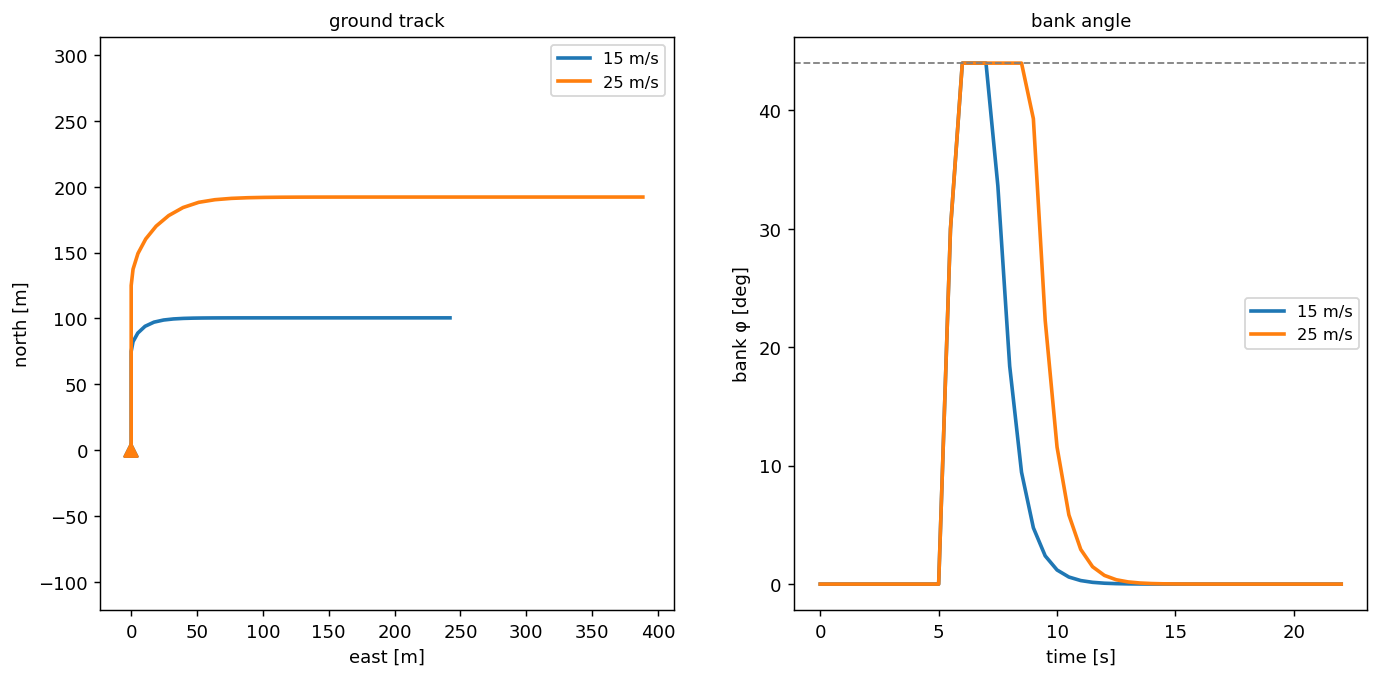

In [3]:
fig, (ax_xy, ax_phi) = plt.subplots(1, 2, figsize=(11.0, 5.2))

def course(s, t):                                          # north, then east at t = 5 s
    return MotionCommand(target_course=0.0 if t < 5.0 else 90.0, target_airspeed=v)

all_x, all_y = [], []
for v, col in ((15.0, "#1f77b4"), (25.0, "#ff7f0e")):
    states = simulate(fw_state(v), course, 22.0)
    xs, ys = track(states)
    all_x += xs; all_y += ys
    ts = [i * DT for i in range(len(states))]
    ax_xy.plot(xs, ys, color=col, lw=2.0, label=f"{v:.0f} m/s")
    ax_xy.plot(xs[0], ys[0], "^", color=col, ms=8)
    ax_phi.plot(ts, [s.bank for s in states], color=col, lw=2.0, label=f"{v:.0f} m/s")

ax_xy.set_title("ground track", fontsize=10)
ax_xy.set_xlabel("east [m]"); ax_xy.set_ylabel("north [m]")
square(ax_xy, all_x, all_y); ax_xy.legend(fontsize=9)

ax_phi.axhline(FW.phi_max, color="0.5", ls="--", lw=1.0)
ax_phi.set_title("bank angle", fontsize=10)
ax_phi.set_xlabel("time [s]"); ax_phi.set_ylabel("bank φ [deg]")
ax_phi.set_box_aspect(1); ax_phi.legend(fontsize=9)
fig.tight_layout(); plt.show()

## Following a path

A position can be flown three ways from the same start. A bare `target_position` steers straight at the point (pure pursuit). Adding `target_leg_start` tracks the leg line with L1 guidance instead — curving onto the line rather than heading at the point. Adding `target_loiter_radius` turns the point into an orbit, since a fixed-wing cannot hover.

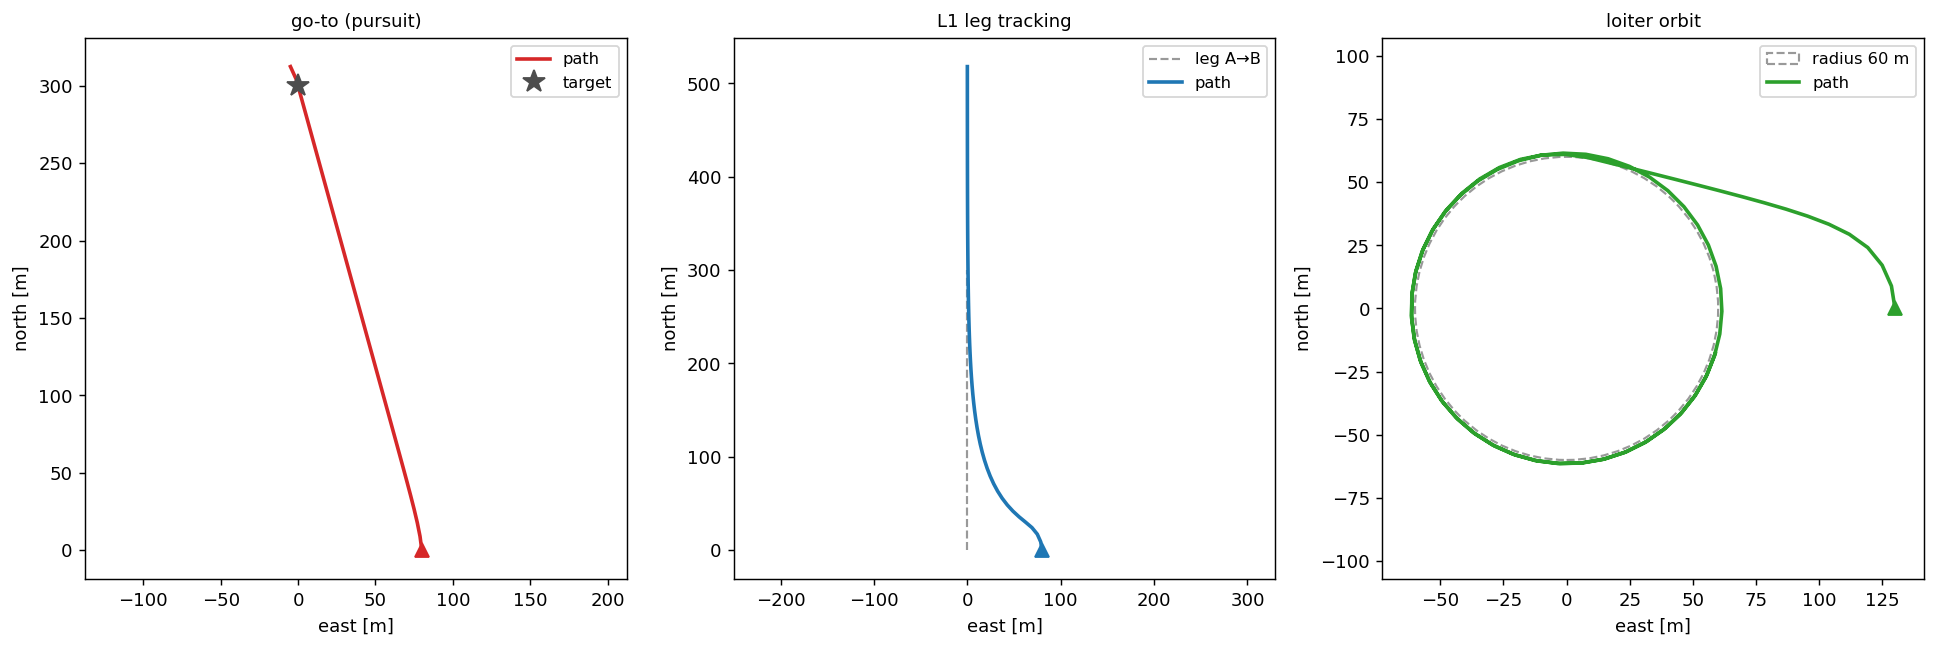

In [4]:
fig, (ax_go, ax_wp, ax_lo) = plt.subplots(1, 3, figsize=(15.0, 5.2))
a, b = (LAT0, LON0), geo.forward(LAT0, LON0, 0.0, 300.0)   # leg A -> B
start = geo.forward(LAT0, LON0, 90.0, 80.0)                # start 80 m off the leg
be, bn = enu(b)

# (1) pure pursuit: bare target_position, steers straight at the point
go = simulate(fw_state(18.0, at=start),
              lambda s, t: MotionCommand(target_position=b, target_airspeed=18.0), 18.0)
xs, ys = track(go)
ax_go.plot(xs, ys, color="#d62728", lw=2.0, label="path")
ax_go.plot(xs[0], ys[0], "^", color="#d62728", ms=8)
ax_go.plot(be, bn, "*", color="0.3", ms=13, label="target")
ax_go.set_title("go-to (pursuit)", fontsize=10); square(ax_go, xs + [be], ys + [bn]); ax_go.legend(fontsize=9)

# (2) L1 waypoint: leg A->B, curves onto the line
wp = simulate(fw_state(18.0, at=start),
              lambda s, t: MotionCommand(target_position=b, target_leg_start=a, target_airspeed=18.0), 30.0)
ae, an = enu(a)
xs, ys = track(wp)
ax_wp.plot([ae, be], [an, bn], color="0.6", ls="--", lw=1.2, label="leg A→B")
ax_wp.plot(xs, ys, color="#1f77b4", lw=2.0, label="path")
ax_wp.plot(xs[0], ys[0], "^", color="#1f77b4", ms=8)
ax_wp.set_title("L1 leg tracking", fontsize=10); square(ax_wp, xs + [ae, be], ys + [an, bn]); ax_wp.legend(fontsize=9)

# (3) loiter: orbit the origin at radius 60 m
radius = 60.0
lo = simulate(fw_state(18.0, at=geo.forward(LAT0, LON0, 90.0, 130.0)),
              lambda s, t: MotionCommand(target_position=(LAT0, LON0), target_loiter_radius=radius, target_airspeed=18.0), 45.0)
xs, ys = track(lo)
ax_lo.add_patch(plt.Circle((0.0, 0.0), radius, color="0.6", ls="--", lw=1.2, fill=False, label=f"radius {radius:.0f} m"))
ax_lo.plot(xs, ys, color="#2ca02c", lw=2.0, label="path")
ax_lo.plot(xs[0], ys[0], "^", color="#2ca02c", ms=8)
ax_lo.set_title("loiter orbit", fontsize=10); square(ax_lo, xs + [-radius, radius], ys + [-radius, radius]); ax_lo.legend(fontsize=9)

for ax in (ax_go, ax_wp, ax_lo):
    ax.set_xlabel("east [m]"); ax.set_ylabel("north [m]")
fig.tight_layout(); plt.show()